In [2]:
import pandas as pd
df = pd.read_csv("amazon_specs_CLEANED.csv")
rodri = pd.read_csv("amazon_specs_enriched_final_rodri.csv")

In [3]:
ev = pd.read_csv("amazon_specs_completo.csv")

In [49]:
ev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6445 entries, 0 to 6444
Columns: 114 entries, category to log_total_reviews
dtypes: bool(2), float64(33), int64(3), object(76)
memory usage: 5.5+ MB


In [51]:
ev.original_title.value_counts()

original_title
OEM Replacement Remote Control for Philips Roku TV URMT21CND016                                                                                                                                       2
GE Big Button Universal Remote Control for Samsung, Vizio, Lg, Sony, Sharp, Roku, Apple TV, TCL, Panasonic, Smart TVs, Streaming Players, Blu-Ray, DVD, 2-Device, Silver, 33701                       2
Insta360 Bullet Time Selfie Stick 2.0Time-Lapse                                                                                                                                                       2
Insta360 X3 Battery                                                                                                                                                                                   2
OEM TCL ROKU RC280 TV REMOTE for LED HDTV with Amazon Netflix HBO Sling Key                                                                                                              

In [5]:
urls = pd.read_csv("../../Datasets/amazon_final_NO_OHE.csv")
urls.head()

,product_title,product_rating,total_reviews,purchased_last_month,original_price,is_best_seller,is_sponsored,coupon,buy_box_availability,sustainability_tags,product_image_url,has_coupon,discount_percentage,product_category,product_segment,log_original_price,log_purchased_last_month,log_total_reviews
0,OWC 2.0TB Aura Pro X2 (GEN 4) SSD Complete Upg...,4.4,358.0,0,239.99,No Badge,Sponsored,No Coupon,1,0,https://m.media-amazon.com/images/I/51vvx1JymA...,0,0.0,PC Components,Media,5.484755,0.000000,5.883322
1,OWC 250GB Aura Pro 6G Flash SSD Upgrade for 20...,4.6,276.0,0,42.99,No Badge,Sponsored,No Coupon,1,0,https://m.media-amazon.com/images/I/41d4RtiB8E...,0,0.0,Storage & Memory Cards,Media,3.783962,0.000000,5.624018
2,HP 67XL Black High-yield Ink Cartridge | Works...,4.6,101072.0,50000,35.89,Best Seller,Organic,No Coupon,0,1,https://m.media-amazon.com/images/I/71y57XPIia...,0,0.0,"Office Supplies, Ink & Toner",Media,3.607941,10.819798,11.523598
3,HP 67 Black/Tri-color Ink Cartridges for HP Pr...,4.6,59092.0,50000,43.89,No Badge,Organic,No Coupon,0,0,https://m.media-amazon.com/images/I/51eBahpKda...,0,0.0,"Office Supplies, Ink & Toner",Media,3.804215,10.819798,10.986868
4,"Sony ZX Series Wired On-Ear Headphones, Black ...",4.5,108926.0,10000,9.54,Best Seller,Organic,No Coupon,0,0,https://m.media-amazon.com/images/I/41CiQ7hR31...,0,0.0,"Audio, Sound & Recording Gear",Baja,2.355178,9.210440,11.598433


In [6]:
# Merge df with urls to get products that exist in both datasets
# 1. Filtramos 'urls' para quedarnos solo con la clave de cruce y la imagen
# Esto evita que se te llenen el dataframe de columnas duplicadas (_x, _y)
urls_subset = urls[['product_title', 'product_image_url']]

# 2. Hacemos el merge
# Usamos 'left' en lugar de 'inner' por seguridad: 
# Si un producto NO tiene imagen, no queremos que desaparezca del dataset, 
# preferimos que tenga NaN en la imagen pero conservar sus datos.
ev_final = ev.merge(
    urls_subset, 
    left_on='original_title', 
    right_on='product_title', 
    how='left' 
)

# 3. (Opcional) Limpieza final
# Como 'original_title' y 'product_title' son lo mismo, podemos borrar la redundante
if 'product_title' in ev_final.columns:
    ev_final = ev_final.drop(columns=['product_title'])

# 4. Rellenar nulos (Buena práctica para el dashboard)
# Si no encuentra imagen, ponemos una URL de "Imagen no disponible" genérica
ev_final['product_image_url'] = ev_final['product_image_url'].fillna("https://via.placeholder.com/150?text=No+Image")

In [9]:
ev_final.drop(columns=['model_used', 'original_row_id', 'error_log'], inplace= True)

In [11]:
from pathlib import Path

out_dir = Path("../../Codigo")
out_dir.mkdir(parents=True, exist_ok=True)
ev_final.to_csv(out_dir / "data_dashboard.csv", index=False)
print(f"Saved: {out_dir / 'data_dashboard.csv'}")

Saved: ..\..\Codigo\data_dashboard.csv


In [10]:
def info_df(df):
    return pd.DataFrame({
    'Columna': df.columns,
    'No Nulos': df.notnull().sum().values,
    'Nulos': df.isnull().sum().values,
    'Tipo Python': df.dtypes.values,
    'Núm. valores': [len(df[col].unique()) for col in df.columns]
     })
info = info_df(ev_final)
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores
0,category,6445,0,object,10
1,subtype,6445,0,object,98
2,market_tier,6445,0,object,4
3,condition,6445,0,object,2
4,is_premium_brand,6445,0,bool,2
...,...,...,...,...,...
107,discount_percentage,6445,0,float64,71
108,log_original_price,6445,0,float64,2656
109,log_purchased_last_month,6445,0,float64,30
110,log_total_reviews,6445,0,float64,3509


In [18]:
ev.is_best_seller.value_counts()

is_best_seller
No Badge             6143
Best Seller           141
Amazon's              137
Limited time deal      17
Save 17%                1
Save 30%                1
Save 77%                1
Save 12%                1
Ends in                 1
Save 18%                1
Save 10%                1
Name: count, dtype: int64

In [6]:
ev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7717 entries, 0 to 7716
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   product_title             7717 non-null   object 
 1   product_rating            7717 non-null   float64
 2   is_best_seller            7717 non-null   object 
 3   is_sponsored              7717 non-null   object 
 4   buy_box_availability      7717 non-null   int64  
 5   sustainability_tags       7717 non-null   int64  
 6   has_coupon                7717 non-null   int64  
 7   discount_percentage       7717 non-null   float64
 8   product_category          7717 non-null   object 
 9   product_segment           7717 non-null   object 
 10  log_original_price        7717 non-null   float64
 11  log_purchased_last_month  7717 non-null   float64
 12  log_total_reviews         7717 non-null   float64
dtypes: float64(5), int64(3), object(5)
memory usage: 783.9+ KB


In [2]:
df.head()

,category,subtype,market_tier,condition,is_premium_brand,tech_generation,brand,confidence,printer_tech,is_color,...,is_original,connector_gender,is_wireless,port_count,storage_type,pd_wattage,model_used,original_title,original_row_id,error_log
0,Displays & Mounting,tv,Mainstream,New,False,Current-Gen,Westinghouse,0.90,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,gpt-4o-mini,"Westinghouse 32 Inch TV, HD LED Small Flat Scr...",0.0,NaN
1,"Office, Printing & Power",toner_ink,Mainstream,New,False,Current-Gen,E-Z Ink,0.95,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,gpt-4o-mini,E-Z Ink Compatible Drum Unit Replacement for B...,1.0,NaN
2,Displays & Mounting,monitor,Mainstream,New,False,Current-Gen,ASUS,0.95,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,gpt-4o-mini,"ASUS TUF Gaming 32"" 1440P HDR Curved Monitor (...",2.0,NaN
3,"Cameras, Photography & Video",mirrorless_dslr,Mainstream,New,True,Current-Gen,Canon,0.95,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,gpt-4o-mini,Canon EOS R6 Mark II Mirrorless Camera RF24-10...,3.0,NaN
4,Out of Scope,excluded,Mainstream,New,False,Current-Gen,AmScope,0.90,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,gpt-4o-mini,AmScope M150 Series Portable LED Monocular Stu...,4.0,NaN


In [4]:
def info_df(df):
    return pd.DataFrame({
    'Columna': df.columns,
    'No Nulos': df.notnull().sum().values,
    'Nulos': df.isnull().sum().values,
    'Tipo Python': df.dtypes.values,
    'Núm. valores': [len(df[col].unique()) for col in df.columns]
     })
info = info_df(df)
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores
0,category,1929,0,object,11
1,subtype,1929,0,object,121
2,market_tier,1929,0,object,4
3,condition,1929,0,object,2
4,is_premium_brand,1929,0,bool,2
...,...,...,...,...,...
98,pd_wattage,17,1912,float64,11
99,model_used,1929,0,object,1
100,original_title,1929,0,object,1929
101,original_row_id,1929,0,float64,1929


In [25]:
urls = pd.read_csv("../../Datasets/amazon_final_NO_OHE.csv")
urls.head()

,product_title,product_rating,total_reviews,purchased_last_month,original_price,is_best_seller,is_sponsored,coupon,buy_box_availability,sustainability_tags,product_image_url,has_coupon,discount_percentage,product_category,product_segment,log_original_price,log_purchased_last_month,log_total_reviews
0,OWC 2.0TB Aura Pro X2 (GEN 4) SSD Complete Upg...,4.4,358.0,0,239.99,No Badge,Sponsored,No Coupon,1,0,https://m.media-amazon.com/images/I/51vvx1JymA...,0,0.0,PC Components,Media,5.484755,0.000000,5.883322
1,OWC 250GB Aura Pro 6G Flash SSD Upgrade for 20...,4.6,276.0,0,42.99,No Badge,Sponsored,No Coupon,1,0,https://m.media-amazon.com/images/I/41d4RtiB8E...,0,0.0,Storage & Memory Cards,Media,3.783962,0.000000,5.624018
2,HP 67XL Black High-yield Ink Cartridge | Works...,4.6,101072.0,50000,35.89,Best Seller,Organic,No Coupon,0,1,https://m.media-amazon.com/images/I/71y57XPIia...,0,0.0,"Office Supplies, Ink & Toner",Media,3.607941,10.819798,11.523598
3,HP 67 Black/Tri-color Ink Cartridges for HP Pr...,4.6,59092.0,50000,43.89,No Badge,Organic,No Coupon,0,0,https://m.media-amazon.com/images/I/51eBahpKda...,0,0.0,"Office Supplies, Ink & Toner",Media,3.804215,10.819798,10.986868
4,"Sony ZX Series Wired On-Ear Headphones, Black ...",4.5,108926.0,10000,9.54,Best Seller,Organic,No Coupon,0,0,https://m.media-amazon.com/images/I/41CiQ7hR31...,0,0.0,"Audio, Sound & Recording Gear",Baja,2.355178,9.210440,11.598433


In [3]:
df.category.value_counts()

category
Office, Printing & Power        423
Accessories                     252
Audio & Media Systems           238
Out of Scope                    163
Peripherals & Input             161
Cameras, Photography & Video    148
PC Components (Core)            125
Computers & Gaming              119
Displays & Mounting             108
Mobile Devices                   99
Networking & Smart Home          93
Name: count, dtype: int64

C:\Users\USER\AppData\Local\Temp\ipykernel_18152\2487866918.py:27: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\USER\anaconda3\envs\TFM\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


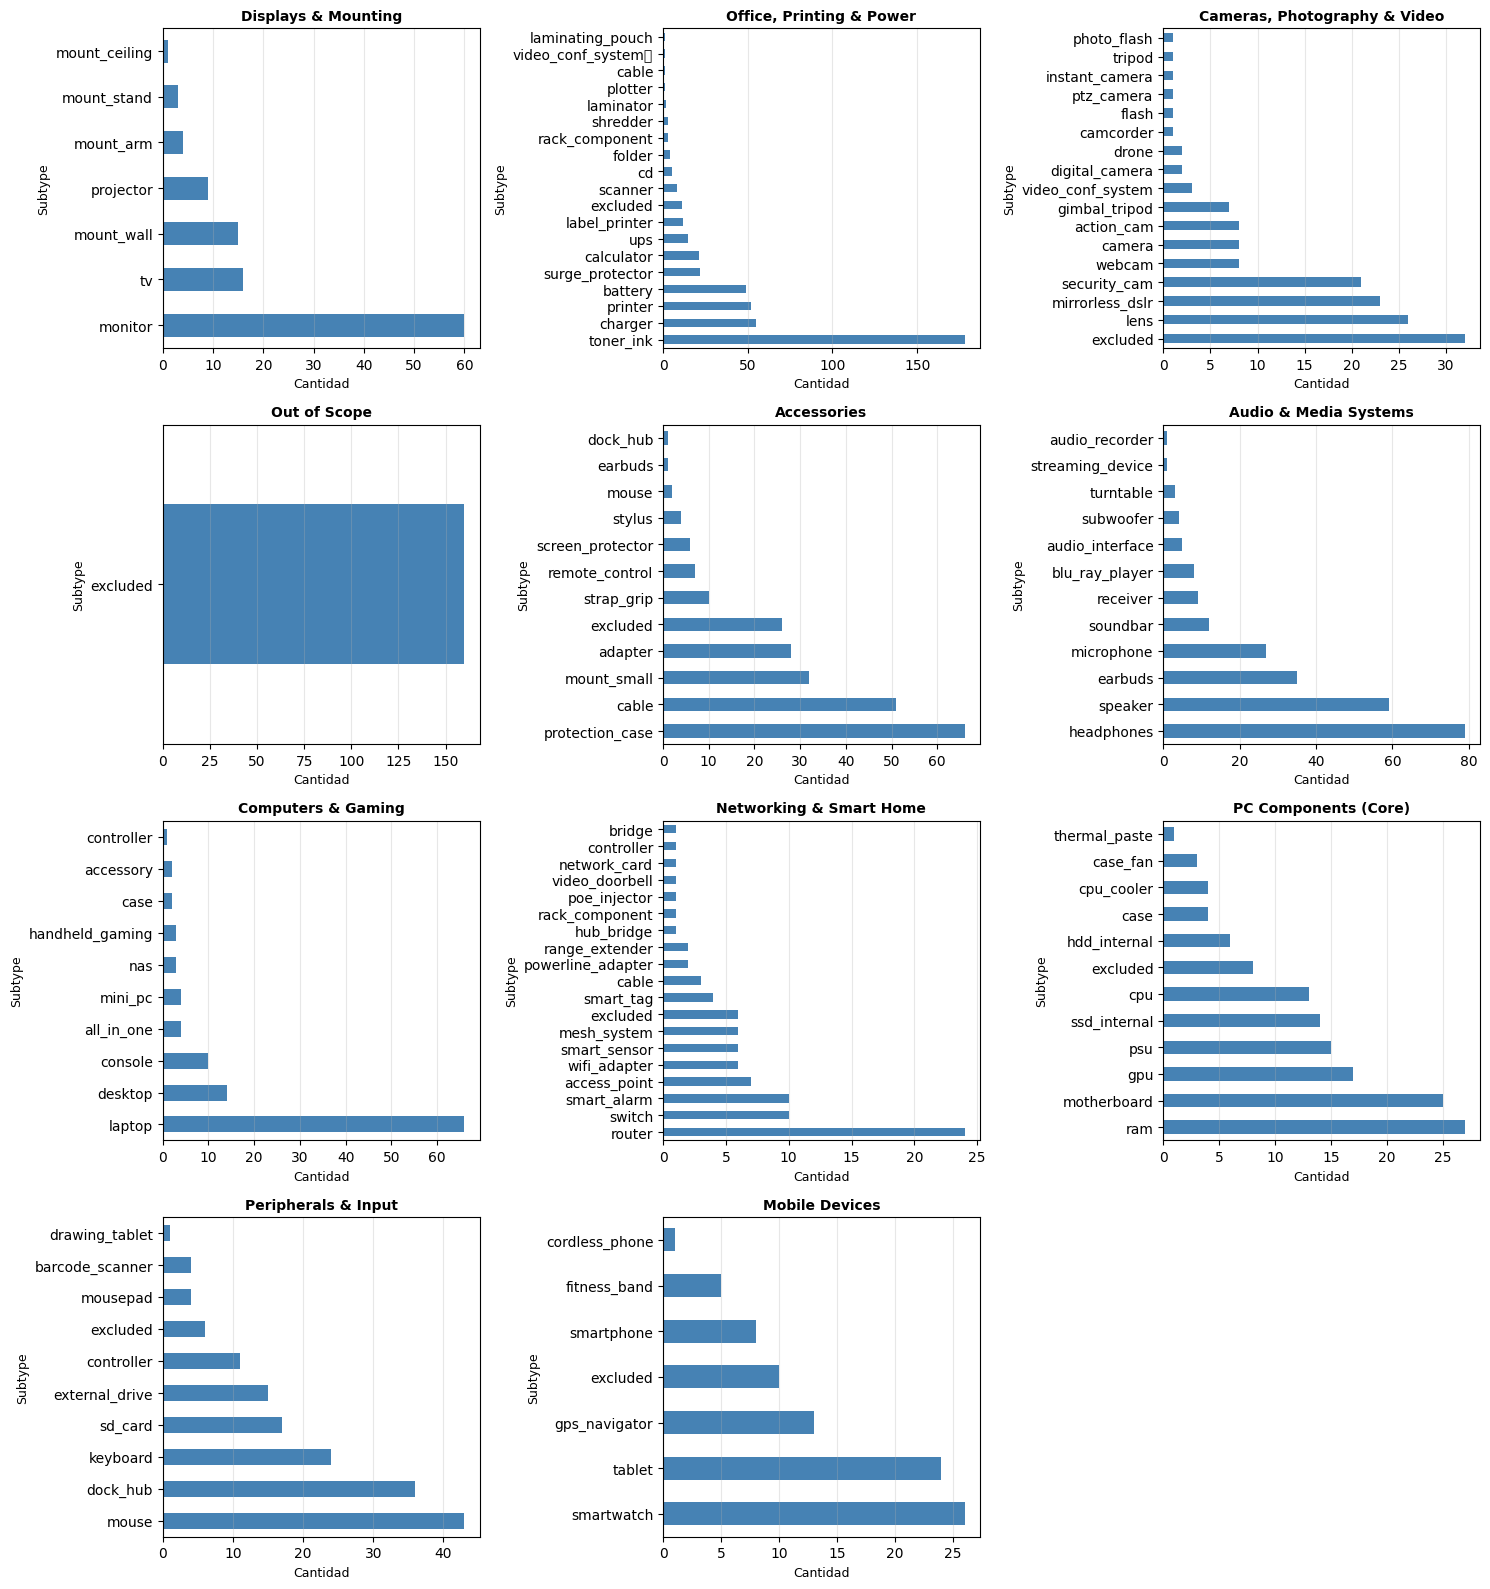

In [18]:
import matplotlib.pyplot as plt

# Obtener todas las categorías únicas
categorias = df['category'].unique()

# Crear un dashboard con subplots en grid de 3 columnas
num_cols = 3
num_rows = (len(categorias) + num_cols - 1) // num_cols  # Redondea hacia arriba

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4*num_rows))
axes = axes.flatten()  # Convierte a array 1D para iterar fácilmente

# Iterar sobre cada categoría y crear una gráfica
for idx, categoria in enumerate(categorias):
    subtype_counts = df[df['category'] == categoria]['subtype'].value_counts()
    
    subtype_counts.plot(kind='barh', ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'{categoria}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Cantidad', fontsize=9)
    axes[idx].set_ylabel('Subtype', fontsize=9)
    axes[idx].grid(axis='x', alpha=0.3)

# Ocultar los subplots vacíos
for idx in range(len(categorias), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [73]:
df[df.category == 'Mobile Devices'].subtype.value_counts()

subtype
smartwatch        26
tablet            24
gps_navigator     16
excluded          10
smartphone         8
fitness_band       5
cordless_phone     1
Name: count, dtype: int64

In [6]:
from IPython.display import Image, HTML


# Merge df with urls to get products that exist in both datasets
merged = df.merge(urls, left_on='original_title', right_on='product_title', how='inner')

# Create new dataset with required columns
new_dataset = merged[['category', 'subtype', 'original_title', 'product_image_url', 'original_row_id']].copy()

new_dataset

# 1. Definimos una función que envuelve la URL en una etiqueta HTML <img>
def render_image(url):
    return f'<img src="{url}" width="80" >'

# 2. Seleccionamos la muestra
sample = new_dataset[(new_dataset['category'] == 'Mobile Devices') & (new_dataset['original_title'].str.contains('Pen'))].sort_values('subtype')

# 3. Mostramos la tabla renderizando el HTML
# 'escape=False' permite que el navegador lea los tags <img> en lugar de verlos como texto
HTML(sample.to_html(escape=False, formatters=dict(product_image_url=render_image)))

,category,subtype,original_title,product_image_url,original_row_id
455,Mobile Devices,smartphone,"Samsung Galaxy S24 Ultra S Pen Replacement, 0.7mm Fine Tip for Precision, Ergonomic Design, Tablet Navigation, Air Command Touch-Free Control, US Version, EJ-PS928BBEGUS, Dark Gray",,456.0
404,Mobile Devices,tablet,"Samsung Galaxy Tab S9 11” 256GB WiFi 7 Android AI Tablet, Snapdragon 8 Gen 2 Processor, AMOLED Screen, Durable Design, S Pen Included, Long Battery Life, Auto Focus Camera, US Version, 2023, Graphite",,405.0
675,Mobile Devices,tablet,"ESR for iPad (A16) 11th Generation Case 11 Inch 2025, iPad 10th Generation Case 10.9 inch 2022, Vertical Stand Cover, Multi Stand Angles, Ultra-Stable Cover with Pencil Holder, Flip Series, Black",,678.0
1199,Mobile Devices,tablet,"SAMSUNG Galaxy Tab S9 Series S Pen for Writing, Drawing, Navigating Tablet, Easy Charging on Magnetic Holder, IP68 Rating, Air Command for Personalized Actions, US Version, EJ-PX710BBEGUJ, Black",,1204.0
1371,Mobile Devices,tablet,"ESR for iPad Pro 11 Inch Case M4 2024(5th Gen), Strong Magnetic Attachment, Slim Trifold Stand Case, Supports Pencil Pro and Pencil(USB-C), Tough Protection, Auto Sleep/Wake, Rebound Series, Black",,1376.0
1433,Mobile Devices,tablet,"Lenovo Tab P12 - Expansive Touchscreen Tablet - 12.7"" 3K Display - 13MP Camera - 8GB Memory - 128GB UFS Storage - Android 13 - Dolby Atmos - Quad JBL Speakers - Pen Included",,1438.0


In [63]:
import pandas as pd
import os

# --- CONFIGURACIÓN ---
INPUT_FILE = "amazon_specs_CLEANED.csv"  # Tu archivo actual
OUTPUT_FILE = "amazon_specs_CLEANED.csv"   # El archivo nuevo corregido

def fix_chargers():
    print(f"📂 Cargando {INPUT_FILE}...")
    
    if not os.path.exists(INPUT_FILE):
        print("❌ Error: No encuentro el archivo.")
        return

    df = pd.read_csv(INPUT_FILE)
    
    # 1. IDENTIFICAR LOS PRODUCTOS A MOVER
    # Condición: Categoría es 'Accessories' Y Subtype es 'charger_aux'
    filtro_chargers = (df['category'] == 'Accessories') & (df['subtype'] == 'charger_aux')
    
    count = filtro_chargers.sum()
    print(f"🔍 Detectados {count} productos mal clasificados como 'charger_aux' en Accessories.")

    if count == 0:
        print("✅ No hay nada que corregir. Todo parece estar bien.")
        return

    # 2. MOVER DATOS DE COLUMNA (Wattage)
    # Copiamos el valor de 'power_wattage' (donde estaba antes) a 'pd_wattage' (donde debe estar en Office)
    # Solo lo hacemos para las filas que cumplen el filtro
    print("⚡ Migrando vatios de 'power_capacity_value' a 'pd_wattage'...")
    df.loc[filtro_chargers, 'pd_wattage'] = df.loc[filtro_chargers, 'power_capacity_value']
    

    # 3. CAMBIAR CATEGORÍA Y SUBTIPO
    print("🏷️ Actualizando etiquetas de categoría y subtipo...")
    df.loc[filtro_chargers, 'category'] = 'Office, Printing & Power'
    df.loc[filtro_chargers, 'subtype'] = 'charger'

    # --- BONUS: ARREGLAR AIRTAGS (Si quieres activarlo, descomenta estas líneas) ---
    # filtro_airtags = (df['original_title'].str.contains("AirTag", case=False, na=False)) & (df['category'] != 'Networking & Smart Home')
    # if filtro_airtags.sum() > 0:
    #     print(f"🍏 Movindo {filtro_airtags.sum()} AirTags a Networking...")
    #     df.loc[filtro_airtags, 'category'] = 'Networking & Smart Home'
    #     df.loc[filtro_airtags, 'subtype'] = 'smart_sensor'

    # 4. GUARDAR
    df.to_csv(OUTPUT_FILE, index=False)
    print(f"🎉 ¡Éxito! Archivo corregido guardado como: {OUTPUT_FILE}")
    print("Ahora tus cargadores tienen la categoría correcta y 'pd_wattage' relleno.")
    
fix_chargers()


def fix_adapters():
    print(f"📂 Cargando {INPUT_FILE}...")
    
    if not os.path.exists(INPUT_FILE):
        print("❌ Error: No encuentro el archivo.")
        return

    df = pd.read_csv(INPUT_FILE)
    
    # 1. IDENTIFICAR LOS PRODUCTOS A MOVER
    # Condición: Categoría es 'Accessories' Y Subtype es 'charger_aux'
    filtro_adapters = (df['category'] == 'Networking & Smart Home') & (df['subtype'] == 'adapter')
    
    count = filtro_adapters.sum()
    print(f"🔍 Detectados {count} productos mal clasificados como 'adapter' en Networking & Smart Home.")

    if count == 0:
        print("✅ No hay nada que corregir. Todo parece estar bien.")
        return
    

    # 3. CAMBIAR CATEGORÍA Y SUBTIPO
    print("🏷️ Actualizando etiquetas de categoría y subtipo...")
    df.loc[filtro_adapters, 'category'] = 'Accessories'

    # 4. GUARDAR
    df.to_csv(OUTPUT_FILE, index=False)
    print(f"🎉 ¡Éxito! Archivo corregido guardado como: {OUTPUT_FILE}")
    
fix_adapters()



def fix_airpods():
    print(f"📂 Cargando {INPUT_FILE}...")
    
    if not os.path.exists(INPUT_FILE):
        print("❌ Error: No encuentro el archivo.")
        return

    df = pd.read_csv(INPUT_FILE)
    
    # 1. IDENTIFICAR LOS PRODUCTOS A MOVER
    filtro_airpods = (df['category'] == 'Mobile Devices') & (df['subtype'] == 'earbuds')
    
    count = filtro_airpods.sum()
    print(f"🔍 Detectados {count} productos mal clasificados como 'earbuds' en Mobile Devices.")

    if count == 0:
        print("✅ No hay nada que corregir. Todo parece estar bien.")
        return
    

    # 3. CAMBIAR CATEGORÍA Y SUBTIPO
    print("🏷️ Actualizando etiquetas de categoría y subtipo...")
    df.loc[filtro_airpods, 'category'] = 'Audio & Media Systems'

    # 4. GUARDAR
    df.to_csv(OUTPUT_FILE, index=False)
    print(f"🎉 ¡Éxito! Archivo corregido guardado como: {OUTPUT_FILE}")
    
fix_airpods()



def fix_airtags():
    print(f"📂 Cargando {INPUT_FILE}...")
    
    if not os.path.exists(INPUT_FILE):
        print("❌ Error: No encuentro el archivo.")
        return

    df = pd.read_csv(INPUT_FILE)
    
    # 1. IDENTIFICAR LOS PRODUCTOS A MOVER
    filtro_airtags = (df['category'] == 'Mobile Devices') & (df['subtype'] == 'smart_tag')
    
    count = filtro_airtags.sum()
    print(f"🔍 Detectados {count} productos mal clasificados como 'smart_tag' en Mobile Devices.")

    if count == 0:
        print("✅ No hay nada que corregir. Todo parece estar bien.")
        return
    

    # 3. CAMBIAR CATEGORÍA Y SUBTIPO
    print("🏷️ Actualizando etiquetas de categoría y subtipo...")
    df.loc[filtro_airtags, 'category'] = 'Networking & Smart Home'

    # 4. GUARDAR
    df.to_csv(OUTPUT_FILE, index=False)
    print(f"🎉 ¡Éxito! Archivo corregido guardado como: {OUTPUT_FILE}")
    
fix_airtags()



def fix_psu_smart():
    print(f"📂 Cargando {INPUT_FILE}...")
    
    if not os.path.exists(INPUT_FILE):
        print("❌ Error: No encuentro el archivo.")
        return

    df = pd.read_csv(INPUT_FILE)
    
    # 1. DEFINICIÓN DE FILTROS LÓGICOS
    
    # A) Debe tener "Power Supply" en el título (Fuente de alimentación)
    has_psu = df['original_title'].str.contains("Power Supply", case=False, na=False)
    
    # B) NO debe tener la palabra "UPS" (Sistema de Alimentación Ininterrumpida)
    # Usamos espacios (" UPS ", "UPS ") o regex boundaries para no confundir con palabras como "SUPER" o "GROUPS"
    # \bUPS\b busca la palabra exacta UPS
    has_ups = df['original_title'].str.contains(r"\bUPS\b", case=False, regex=True, na=False)
    
    # C) NO debe tener "Battery Backup" (otra forma común de llamar a los SAIs)
    has_battery = df['original_title'].str.contains("Battery Backup", case=False, na=False)
    
    # D) Que no esté ya en la categoría correcta
    not_already_core = df['category'] != 'PC Components (Core)'

    # --- LÓGICA FINAL ---
    # Queremos: (Tiene Power Supply) Y (NO es UPS) Y (NO es Batería) Y (No está ya clasificado)
    # El símbolo ~ significa "NO" (negación)
    filtro_final = has_psu & (~has_ups) & (~has_battery) & not_already_core
    
    count = filtro_final.sum()
    print(f"🔍 Detectadas {count} fuentes de alimentación reales (excluyendo UPS/SAIs).")

    if count == 0:
        print("✅ No hay nada que corregir.")
        return

    # 2. LIMPIEZA Y REUBICACIÓN
    print("🧹 Limpiando columnas de UPS (capacity_value y unit) para estos productos...")
    df.loc[filtro_final, 'ups_capacity_value'] = None
    df.loc[filtro_final, 'ups_capacity_unit'] = None

    print("🏷️ Moviendo a 'PC Components (Core)' con subtipo 'psu'...")
    df.loc[filtro_final, 'category'] = 'PC Components (Core)'
    df.loc[filtro_final, 'subtype'] = 'psu'

    # 3. GUARDAR
    df.to_csv(OUTPUT_FILE, index=False)
    print(f"🎉 ¡Éxito! Archivo corregido guardado en: {OUTPUT_FILE}")

fix_psu_smart()



PHRASE_TO_REMOVE = "Instant Film"

def remove_instant_film_verbose():
    print(f"📂 Cargando {INPUT_FILE}...")
    
    if not os.path.exists(INPUT_FILE):
        print("❌ Error: No encuentro el archivo.")
        return

    df = pd.read_csv(INPUT_FILE)
    initial_count = len(df)
    
    # 1. IDENTIFICAR FILAS A BORRAR
    # Buscamos la frase en 'original_title', ignorando mayúsculas
    mask_to_remove = df['original_title'].str.contains(PHRASE_TO_REMOVE, case=False, na=False)
    
    # Obtener los títulos que vamos a borrar
    titulos_a_borrar = df.loc[mask_to_remove, 'original_title'].tolist()
    count_to_remove = len(titulos_a_borrar)
    
    if count_to_remove == 0:
        print(f"✅ No se encontraron productos con '{PHRASE_TO_REMOVE}'.")
        return

    # 2. IMPRIMIR LOS TÍTULOS (LO QUE PEDISTE)
    print(f"\n🗑️ SE VAN A ELIMINAR ESTOS {count_to_remove} PRODUCTOS:")
    print("="*60)
    for i, titulo in enumerate(titulos_a_borrar, 1):
        print(f"{i}. {titulo[:100]}...") # Imprime los primeros 100 caracteres
    print("="*60)

    # 3. FILTRAR Y GUARDAR
    df_cleaned = df[~mask_to_remove]
    df_cleaned.to_csv(OUTPUT_FILE, index=False)
    
    print(f"\n💾 Archivo actualizado guardado en: {OUTPUT_FILE}")
    print(f"📊 Antes: {initial_count} -> Ahora: {len(df_cleaned)} filas.")


remove_instant_film_verbose()



def fix_speakerphone():
    print(f"📂 Cargando {INPUT_FILE}...")
    
    if not os.path.exists(INPUT_FILE):
        print("❌ Error: No encuentro el archivo.")
        return

    df = pd.read_csv(INPUT_FILE)
    
    # 1. IDENTIFICAR LOS PRODUCTOS A MOVER
    # Condición: Categoría es 'Accessories' Y Subtype es 'charger_aux'
    filtro_speakerphone = (df['category'] == 'Audio & Media Systems') & (df['subtype'] == 'speakerphone')
    
    count = filtro_speakerphone.sum()
    print(f"🔍 Detectados {count} productos mal clasificados como 'charger_aux' en Accessories.")

    if count == 0:
        print("✅ No hay nada que corregir. Todo parece estar bien.")
        return

    # 2. MOVER DATOS DE COLUMNA (Wattage)
    # Copiamos el valor de 'power_wattage' (donde estaba antes) a 'pd_wattage' (donde debe estar en Office)
    # Solo lo hacemos para las filas que cumplen el filtro
    print("⚡ Migrando vatios de 'power_capacity_value' a 'pd_wattage'...")
    df.loc[filtro_speakerphone, 'pd_wattage'] = df.loc[filtro_speakerphone, 'power_capacity_value']
    

    # 3. CAMBIAR CATEGORÍA Y SUBTIPO
    print("🏷️ Actualizando etiquetas de categoría y subtipo...")
    df.loc[filtro_speakerphone, 'category'] = 'Audio & Media Systems'
    df.loc[filtro_speakerphone, 'subtype'] = 'speaker'

    # --- BONUS: ARREGLAR AIRTAGS (Si quieres activarlo, descomenta estas líneas) ---
    # filtro_airtags = (df['original_title'].str.contains("AirTag", case=False, na=False)) & (df['category'] != 'Networking & Smart Home')
    # if filtro_airtags.sum() > 0:
    #     print(f"🍏 Movindo {filtro_airtags.sum()} AirTags a Networking...")
    #     df.loc[filtro_airtags, 'category'] = 'Networking & Smart Home'
    #     df.loc[filtro_airtags, 'subtype'] = 'smart_sensor'

    # 4. GUARDAR
    df.to_csv(OUTPUT_FILE, index=False)
    print(f"🎉 ¡Éxito! Archivo corregido guardado como: {OUTPUT_FILE}")
    print("Ahora tus cargadores tienen la categoría correcta y 'pd_wattage' relleno.")
    
fix_speakerphone()



def fix_adapters2():
    print(f"📂 Cargando {INPUT_FILE}...")
    
    if not os.path.exists(INPUT_FILE):
        print("❌ Error: No encuentro el archivo.")
        return

    df = pd.read_csv(INPUT_FILE)
    
    # 1. IDENTIFICAR LOS PRODUCTOS A MOVER
    # Condición: Categoría es 'Accessories' Y Subtype es 'charger_aux'
    filtro_adapters = (df['category'] == 'Peripherals & Input') & (df['subtype'] == 'adapter')
    
    count = filtro_adapters.sum()
    print(f"🔍 Detectados {count} productos mal clasificados como 'adapter' en Networking & Smart Home.")

    if count == 0:
        print("✅ No hay nada que corregir. Todo parece estar bien.")
        return
    

    # 3. CAMBIAR CATEGORÍA Y SUBTIPO
    print("🏷️ Actualizando etiquetas de categoría y subtipo...")
    df.loc[filtro_adapters, 'category'] = 'Accessories'

    # 4. GUARDAR
    df.to_csv(OUTPUT_FILE, index=False)
    print(f"🎉 ¡Éxito! Archivo corregido guardado como: {OUTPUT_FILE}")
    
fix_adapters2()

📂 Cargando amazon_specs_CLEANED.csv...
🔍 Detectados 28 productos mal clasificados como 'charger_aux' en Accessories.
⚡ Migrando vatios de 'power_capacity_value' a 'pd_wattage'...
🏷️ Actualizando etiquetas de categoría y subtipo...
🎉 ¡Éxito! Archivo corregido guardado como: amazon_specs_CLEANED.csv
Ahora tus cargadores tienen la categoría correcta y 'pd_wattage' relleno.
📂 Cargando amazon_specs_CLEANED.csv...
🔍 Detectados 0 productos mal clasificados como 'adapter' en Networking & Smart Home.
✅ No hay nada que corregir. Todo parece estar bien.
📂 Cargando amazon_specs_CLEANED.csv...
🔍 Detectados 2 productos mal clasificados como 'earbuds' en Mobile Devices.
🏷️ Actualizando etiquetas de categoría y subtipo...
🎉 ¡Éxito! Archivo corregido guardado como: amazon_specs_CLEANED.csv
📂 Cargando amazon_specs_CLEANED.csv...
🔍 Detectados 0 productos mal clasificados como 'smart_tag' en Mobile Devices.
✅ No hay nada que corregir. Todo parece estar bien.
📂 Cargando amazon_specs_CLEANED.csv...
🔍 Detect

In [20]:
import pandas as pd
import os

# --- CONFIGURACIÓN ---
INPUT_FILE = "amazon_specs_enriched_final.csv"  # Tu archivo actual
OUTPUT_FILE = "amazon_specs_CLEANED.csv"   # El archivo nuevo corregido

def fix_speakerphone():
    print(f"📂 Cargando {INPUT_FILE}...")
    
    if not os.path.exists(INPUT_FILE):
        print("❌ Error: No encuentro el archivo.")
        return

    df = pd.read_csv(INPUT_FILE)
    
    # 1. IDENTIFICAR LOS PRODUCTOS A MOVER
    # Condición: Categoría es 'Accessories' Y Subtype es 'charger_aux'
import pandas as pd
import os

import pandas as pd
import os

# --- CONFIGURACIÓN ---
FILE_PATH = "amazon_specs_CLEANED.csv"

# --- DICCIONARIO DE DATOS ---
# Formato: "Parte única del título": Capacidad en GB
# NOTA: Los CDs suelen ser de 700MB = 0.7 GB
#       Los DVDs son de 4.7 GB
#       Los Blu-Ray son de 25 GB o 50 GB
CD_MAP = {
    # Ejemplo 1: Título exacto o parcial -> 700MB (0.7 GB)
    """Verbatim DVD+R Blank Discs AZO Dye 4.7GB 16X Recordable Disc - 100 Discs Spindle Silver Frustration Free Packaging""": 4.7,
    """Verbatim BD-R 25GB 16X Blu-ray Recordable Media Disc - 50 Pack Spindle - 98397""": 25,
    """Verbatim DVD-R Blank Discs AZO Dye 4.7GB 16X Recordable Disc - 50 Pack Spindle,Silver""": 4.7,
    """VER96155 - CD-R, 40X, 700MB/80Min, Branded, 25/PK""": 0.7,
    """Verbatim DVD+R DL Double Layer 8.5GB 8X LifeSeries - 25pk Spindle 71122""": 8.5,
}

def update_cds_manually():
    print(f"📂 Cargando {FILE_PATH}...")
    
    if not os.path.exists(FILE_PATH):
        print("❌ Error: No encuentro el archivo.")
        return

    df = pd.read_csv(FILE_PATH)
    total_modificados = 0

    print("\n💿 Iniciando actualización de CDs...")

    for titulo_parcial, gigas in CD_MAP.items():
        # Buscamos el producto que contenga ese texto (regex=False para evitar problemas con paréntesis)
        mask = df['original_title'].str.contains(titulo_parcial, case=False, regex=False, na=False)
        
        count = mask.sum()
        
        if count > 0:
            # 1. Aplicar cambios
            df.loc[mask, 'subtype'] = 'cd'  # Asignamos el subtipo nuevo
            df.loc[mask, 'storage_gb'] = gigas # Asignamos el almacenamiento manual
            
            # 2. Asegurarnos de que están en Office (por si acaso estaban en otro lado)
            df.loc[mask, 'category'] = 'Office, Printing & Power'
            
            print(f"   ✅ Actualizados {count} registros para: '{titulo_parcial[:30]}...' -> {gigas} GB")
            total_modificados += count
        else:
            print(f"   ⚠️ NO ENCONTRADO: '{titulo_parcial[:30]}...'")

    if total_modificados > 0:
        # Guardar
        df.to_csv(FILE_PATH, index=False)
        print(f"\n💾 Guardado. Se han modificado {total_modificados} filas en total.")
    else:
        print("\n🤷♂️ No se realizaron cambios (revisa los títulos).")


update_cds_manually()

📂 Cargando amazon_specs_CLEANED.csv...

💿 Iniciando actualización de CDs...
   ✅ Actualizados 1 registros para: 'Verbatim DVD+R Blank Discs AZO...' -> 4.7 GB
   ✅ Actualizados 1 registros para: 'Verbatim BD-R 25GB 16X Blu-ray...' -> 25 GB
   ✅ Actualizados 1 registros para: 'Verbatim DVD-R Blank Discs AZO...' -> 4.7 GB
   ✅ Actualizados 1 registros para: 'VER96155 - CD-R, 40X, 700MB/80...' -> 0.7 GB
   ✅ Actualizados 1 registros para: 'Verbatim DVD+R DL Double Layer...' -> 8.5 GB

💾 Guardado. Se han modificado 5 filas en total.


ARREGLOS DIEGO

In [52]:
df.category.value_counts()

category
Office, Printing & Power        423
Accessories                     261
Audio & Media Systems           241
Out of Scope                    163
Peripherals & Input             162
Cameras, Photography & Video    147
PC Components (Core)            128
Displays & Mounting             108
Computers & Gaming              107
Mobile Devices                   95
Networking & Smart Home          94
Name: count, dtype: int64

In [17]:
df = pd.read_csv("amazon_specs_CLEANED.csv")

In [79]:
df[df.category == 'Office, Printing & Power'].subtype.value_counts()

subtype
toner_ink              178
charger                 55
printer                 52
battery                 49
surge_protector         22
calculator              21
ups                     15
label_printer           12
excluded                11
scanner                  8
cd                       5
folder                   4
rack_component           3
shredder                 3
laminator                2
plotter                  1
cable                    1
video_conf_system\t      1
laminating_pouch         1
Name: count, dtype: int64

In [7]:
import pandas as pd
import os

# --- CONFIGURACIÓN ---
INPUT_FILE = "amazon_specs_CLEANED.csv"
OUTPUT_FILE = "amazon_specs_CLEANED.csv"

def fix_phone_grips():
    print(f"📂 Cargando {INPUT_FILE}...")
    
    if not os.path.exists(INPUT_FILE):
        print("❌ Error: No encuentro el archivo.")
        return

    df = pd.read_csv(INPUT_FILE)
    
    # 1. IDENTIFICAR LOS PRODUCTOS (Lógica estricta)
    # Usamos regex=True para activar expresiones regulares.
    # \b significa "Límite de palabra". 
    # \bGrip\b busca exactamente "Grip" aislado.
    # case=False permite "Grip", "grip" o "GRIP", pero NO "Grips" ni "Gripping".
    filtro_airpods = df['category'] == 'Accessories'
    filtro_grip = df['original_title'].str.contains(r"\bGrip\b", case=False, regex=True, na=False)
    
    # Opcional: Asegurarnos de que no estamos moviendo cosas que no son accesorios
    # (aunque un PopSocket suele ser siempre accesorio)
    # Si quieres ser muy estricto y solo mover los que la IA dijo que eran fundas:
    # filtro_extra = df['subtype'] == 'protection_case'
    # filtro_final = filtro_grip & filtro_extra
    
    # Usamos el filtro directo para atrapar todos los grips mal puestos
    filtro_final = filtro_grip & filtro_airpods
    
    count = filtro_final.sum()
    print(f"🔍 Detectados {count} productos con la palabra exacta 'Grip'.")

    if count == 0:
        print("✅ No se encontró nada. Revisa si los títulos tienen 'Grip' separado por espacios.")
        return
    
    # 2. MOSTRAR EJEMPLOS (Para verificar que no se cuela 'Gripping')
    print("\n📝 Ejemplos detectados (Verifica que no hay plurales):")
    print(df.loc[filtro_final, 'original_title'].head(12).to_string(index=False))

    # 3. MOVER A 'strap_grip'
    print("\n🏷️ Moviendo a 'Accessories' -> 'strap_grip'...")
    df.loc[filtro_final, 'category'] = 'Accessories'
    df.loc[filtro_final, 'subtype'] = 'strap_grip'

    # 4. GUARDAR
    df.to_csv(OUTPUT_FILE, index=False)
    print(f"🎉 ¡Éxito! Archivo actualizado: {OUTPUT_FILE}")

fix_phone_grips()

📂 Cargando amazon_specs_CLEANED.csv...
🔍 Detectados 9 productos con la palabra exacta 'Grip'.

📝 Ejemplos detectados (Verifica que no hay plurales):
​​​​PopSockets Phone Grip with Expanding Kickst...
PopSockets Phone Grip for MagSafe with Kickstan...
OtterBox Made for Kids Case for iPad (A16) & iP...
PopSockets Phone Grip with Expanding Kickstand,...
​​​​PopSockets Phone Grip with Expanding Kickst...
PopSockets Phone Grip for MagSafe with Kickstan...
​​​​PopSockets Phone Grip with Expanding Kickst...
PopSockets Plant-Based Phone Grip with Expandin...
PopSockets Phone Grip for MagSafe with Kickstan...

🏷️ Moviendo a 'Accessories' -> 'strap_grip'...
🎉 ¡Éxito! Archivo actualizado: amazon_specs_CLEANED.csv


In [24]:
df.category.value_counts()

category
Office, Printing & Power        423
Accessories                     255
Audio & Media Systems           240
Out of Scope                    163
Peripherals & Input             155
Cameras, Photography & Video    148
PC Components (Core)            126
Computers & Gaming              119
Displays & Mounting             108
Mobile Devices                   99
Networking & Smart Home          93
Name: count, dtype: int64

In [13]:
import pandas as pd
import os

# --- CONFIGURACIÓN ---
INPUT_FILE = "amazon_specs_CLEANED.csv"  # Tu archivo actual
OUTPUT_FILE = "amazon_specs_CLEANED.csv"   # El archivo nuevo corregido

def fix_adapters():
    print(f"📂 Cargando {INPUT_FILE}...")
    
    if not os.path.exists(INPUT_FILE):
        print("❌ Error: No encuentro el archivo.")
        return

    df = pd.read_csv(INPUT_FILE)
    
    # 1. IDENTIFICAR LOS PRODUCTOS A MOVER
    # Condición: Categoría es 'Accessories' Y Subtype es 'charger_aux'
    filtro_adapters = (df['category'] == 'PC Components (Core)') & (df['subtype'] == 'cpu cooler')
    
    count = filtro_adapters.sum()
    print(f"🔍 Detectados {count} productos mal clasificados como 'adapter' en Networking & Smart Home.")

    if count == 0:
        print("✅ No hay nada que corregir. Todo parece estar bien.")
        return
    

    # 3. CAMBIAR CATEGORÍA Y SUBTIPO
    print("🏷️ Actualizando etiquetas de categoría y subtipo...")
    df.loc[filtro_adapters, 'subtype'] = 'cpu_cooler'

    # 4. GUARDAR
    df.to_csv(OUTPUT_FILE, index=False)
    print(f"🎉 ¡Éxito! Archivo corregido guardado como: {OUTPUT_FILE}")
    
fix_adapters()

📂 Cargando amazon_specs_CLEANED.csv...
🔍 Detectados 1 productos mal clasificados como 'adapter' en Networking & Smart Home.
🏷️ Actualizando etiquetas de categoría y subtipo...
🎉 ¡Éxito! Archivo corregido guardado como: amazon_specs_CLEANED.csv


In [26]:
df.category.value_counts()

category
Office, Printing & Power        444
Audio & Media Systems           241
Accessories                     222
Out of Scope                    163
Peripherals & Input             161
Cameras, Photography & Video    148
PC Components (Core)            134
Computers & Gaming              119
Displays & Mounting             108
Mobile Devices                   97
Networking & Smart Home          92
Name: count, dtype: int64

In [70]:
df[df['category'] == 'Accessories'].subtype.value_counts()

subtype
protection_case     72
cable               51
mount_small         32
adapter             28
excluded            26
remote_control       6
screen_protector     6
stylus               4
strap_grip           4
mouse                2
earbuds              1
dock_hub             1
Name: count, dtype: int64

In [71]:
import pandas as pd
import os

# --- CONFIGURACIÓN ---
INPUT_FILE = "amazon_specs_CLEANED.csv"  # Tu archivo actual
OUTPUT_FILE = "amazon_specs_CLEANED.csv"   # El archivo nuevo corregido

def fix_airpods():
    print(f"📂 Cargando {INPUT_FILE}...")
    
    if not os.path.exists(INPUT_FILE):
        print("❌ Error: No encuentro el archivo.")
        return

    df = pd.read_csv(INPUT_FILE)
    
    # 1. IDENTIFICAR LOS PRODUCTOS A MOVER
    filtro_airpods = df.loc[517]
    
    # count = filtro_airpods.sum()
    # print(f"🔍 Detectados {count} productos mal clasificados como 'earbuds' en Mobile Devices.")
    print(filtro_airpods.subtype)

    # if count == 0:
    #     print("✅ No hay nada que corregir. Todo parece estar bien.")
    #     return
    

    # # 3. CAMBIAR CATEGORÍA Y SUBTIPO
    print("🏷️ Actualizando etiquetas de categoría y subtipo...")
    df.loc[517, 'category'] = 'Accessories'
    df.loc[517, 'subtype'] = 'remote_control'
    

    # # 4. GUARDAR
    df.to_csv(OUTPUT_FILE, index=False)
    print(f"🎉 ¡Éxito! Archivo corregido guardado como: {OUTPUT_FILE}")
    
fix_airpods()

📂 Cargando amazon_specs_CLEANED.csv...
excluded
🏷️ Actualizando etiquetas de categoría y subtipo...
🎉 ¡Éxito! Archivo corregido guardado como: amazon_specs_CLEANED.csv


In [13]:
df = pd.read_csv("amazon_specs_CLEANED.csv" )

# 1. IDENTIFICAR LOS PRODUCTOS A MOVER
# Creamos las condiciones por separado para que el código sea legible
condicion_cat = df['category'] == 'Peripherals & Input'
condicion_sub = df['subtype'] == 'external_drive'

# Pasamos a minúsculas una sola vez para que sea más eficiente
title_lower = df['original_title'].str.lower()

# Lógica: Contiene 'memory card' O (contiene 'card' Y contiene 'sdxc')
condicion_titulo = (title_lower.str.contains('memory card')) | \
                (title_lower.str.contains('card') & title_lower.str.contains('sdxc'))

# Aplicamos los filtros y ordenamos
filtered_df = df[condicion_cat & condicion_sub & condicion_titulo]
# count = filtered_df.sum()

filtered_df

,category,subtype,market_tier,condition,is_premium_brand,tech_generation,brand,confidence,printer_tech,is_color,...,is_original,connector_gender,is_wireless,port_count,storage_type,pd_wattage,model_used,original_title,original_row_id,error_log
33,Peripherals & Input,external_drive,Mainstream,New,True,Current-Gen,SanDisk,0.95,NaN,NaN,...,NaN,NaN,NaN,NaN,Flash,NaN,gpt-4o-mini,SanDisk 32GB Extreme CompactFlash Memory Card ...,33.0,NaN
42,Peripherals & Input,external_drive,Mainstream,New,False,Current-Gen,SanDisk,0.95,NaN,NaN,...,NaN,NaN,NaN,NaN,Flash,NaN,gpt-4o-mini,SanDisk 128GB Ultra SDXC UHS-I Memory Card - 1...,42.0,NaN
153,Peripherals & Input,external_drive,Mainstream,New,True,Current-Gen,SanDisk,0.95,NaN,NaN,...,NaN,NaN,NaN,NaN,Flash,NaN,gpt-4o-mini,SanDisk 1TB Extreme microSDXC UHS-I Memory Car...,153.0,NaN
230,Peripherals & Input,external_drive,Mainstream,New,False,Current-Gen,SanDisk,0.95,NaN,NaN,...,NaN,NaN,NaN,NaN,Flash,NaN,gpt-4o-mini,SanDisk 128GB Ultra SDXC UHS-I Memory Card - 1...,230.0,NaN
529,Peripherals & Input,external_drive,Mainstream,New,True,Current-Gen,SanDisk,0.95,NaN,NaN,...,NaN,NaN,NaN,NaN,Flash,NaN,gpt-4o-mini,SanDisk 64GB Extreme CompactFlash Memory Card ...,529.0,NaN
767,Peripherals & Input,external_drive,Mainstream,New,False,Current-Gen,SanDisk,0.95,NaN,NaN,...,NaN,NaN,NaN,NaN,Flash,NaN,gpt-4o-mini,[Older Version] SanDisk 128GB Ultra microSDXC ...,767.0,NaN
1500,Peripherals & Input,external_drive,Mainstream,New,True,Current-Gen,Sony,0.95,NaN,NaN,...,NaN,NaN,NaN,NaN,Flash,NaN,gpt-4o-mini,"Sony TOUGH-G series SDXC UHS-II Card 128GB, V9...",1500.0,NaN
1731,Peripherals & Input,external_drive,Mainstream,New,False,Current-Gen,KODAK,0.90,NaN,NaN,...,NaN,NaN,NaN,NaN,Flash,NaN,gpt-4o-mini,"KODAK SDXC Card 128GB UHS-I U1 V10 Premium, up...",1731.0,NaN


In [18]:
import os
# --- CONFIGURACIÓN ---
INPUT_FILE = "amazon_specs_CLEANED.csv"  # Tu archivo actual
OUTPUT_FILE = "amazon_specs_CLEANED.csv"   # El archivo nuevo corregido

def fix_airtags():
    print(f"📂 Cargando {INPUT_FILE}...")
    
    if not os.path.exists(INPUT_FILE):
        print("❌ Error: No encuentro el archivo.")
        return

    df = pd.read_csv(INPUT_FILE)
    
    # 1. IDENTIFICAR LOS PRODUCTOS A MOVER
    # Creamos las condiciones por separado para que el código sea legible
    condicion_cat = df['category'] == 'Peripherals & Input'
    condicion_sub = df['subtype'] == 'external_drive'

    # Pasamos a minúsculas una sola vez para que sea más eficiente
    title_lower = df['original_title'].str.lower()

    # Lógica: Contiene 'memory card' O (contiene 'card' Y contiene 'sdxc')
    condicion_titulo = (title_lower.str.contains('memory card')) | \
                    (title_lower.str.contains('card') & title_lower.str.contains('sdxc'))

    # Aplicamos los filtros y ordenamos
    filtered_df = new_dataset[condicion_cat & condicion_sub & condicion_titulo]
    filtro = (condicion_cat & condicion_sub & condicion_titulo)
    count = filtro.sum()
    print(f"🔍 Detectados {count} productos mal clasificados como 'mouse' en Accesories.")

    if count == 0:
        print("✅ No hay nada que corregir. Todo parece estar bien.")
        return
    

    # 3. CAMBIAR CATEGORÍA Y SUBTIPO
    print("🏷️ Actualizando etiquetas de categoría y subtipo...")
    df.loc[filtro, 'subtype'] = 'sd_card'

    # 4. GUARDAR
    df.to_csv(OUTPUT_FILE, index=False)
    print(f"🎉 ¡Éxito! Archivo corregido guardado como: {OUTPUT_FILE}")
    
fix_airtags()

📂 Cargando amazon_specs_CLEANED.csv...
🔍 Detectados 8 productos mal clasificados como 'mouse' en Accesories.
🏷️ Actualizando etiquetas de categoría y subtipo...
🎉 ¡Éxito! Archivo corregido guardado como: amazon_specs_CLEANED.csv


In [41]:
df.category.value_counts()


category
Office, Printing & Power        423
Accessories                     252
Audio & Media Systems           238
Out of Scope                    163
Peripherals & Input             161
Cameras, Photography & Video    148
PC Components (Core)            125
Computers & Gaming              119
Displays & Mounting             108
Mobile Devices                   99
Networking & Smart Home          93
Name: count, dtype: int64

In [46]:
new_dataset.head()

,category,subtype,original_title,product_image_url
0,Displays & Mounting,tv,"Westinghouse 32 Inch TV, HD LED Small Flat Scr...",https://m.media-amazon.com/images/I/71oLgTxdxA...
1,"Office, Printing & Power",toner_ink,E-Z Ink Compatible Drum Unit Replacement for B...,https://m.media-amazon.com/images/I/81C-N6PmzW...
2,Displays & Mounting,monitor,"ASUS TUF Gaming 32"" 1440P HDR Curved Monitor (...",https://m.media-amazon.com/images/I/71GCas7Vm0...
3,"Cameras, Photography & Video",mirrorless_dslr,Canon EOS R6 Mark II Mirrorless Camera RF24-10...,https://m.media-amazon.com/images/I/61S4Op1us3...
4,Out of Scope,excluded,AmScope M150 Series Portable LED Monocular Stu...,https://m.media-amazon.com/images/I/51bA57i3Hg...


In [47]:
filtered_df.head()

,category,subtype,original_title,product_image_url
26,Displays & Mounting,mount_wall,Sanus Universal Low Profile Tilt TV Wall Mount...,https://m.media-amazon.com/images/I/71BwhTOl6J...
39,"Office, Printing & Power",battery,ACDelco AA and AAA 48-Count Combo Pack Super A...,https://m.media-amazon.com/images/I/91GQhkeCHR...
83,"Office, Printing & Power",toner_ink,Canon Genuine 055 Black Toner Cartridge Compat...,https://m.media-amazon.com/images/I/61aisuGXyr...
105,"Cameras, Photography & Video",mirrorless_dslr,Sony a7 III (ILCEM3K/B) Full-frame Mirrorless ...,https://m.media-amazon.com/images/I/517CEyCXIH...
121,"Office, Printing & Power",toner_ink,Verbatim DVD-R Blank Discs AZO Dye 4.7GB 16X R...,https://m.media-amazon.com/images/I/81gvBX7Wgv...


In [ ]:
filtered_df = new_dataset[(new_dataset.category == 'PC Components (Core)')][['subtype','original_title', 'product_image_url']]



# 1. Definimos una función que envuelve la URL en una etiqueta HTML <img>
def render_image(url):
    return f'<img src="{url}" width="80" >'


# 3. Mostramos la tabla renderizando el HTML
# 'escape=False' permite que el navegador lea los tags <img> en lugar de verlos como texto
HTML(filtered_df.to_html(escape=False, formatters=dict(product_image_url=render_image)))

In [58]:
df.category.value_counts()

category
Office, Printing & Power        423
Accessories                     252
Audio & Media Systems           238
Out of Scope                    163
Peripherals & Input             161
Cameras, Photography & Video    148
PC Components (Core)            125
Computers & Gaming              119
Displays & Mounting             108
Mobile Devices                   99
Networking & Smart Home          93
Name: count, dtype: int64

In [68]:
df[df.category == 'PC Components (Core)'].subtype.value_counts()

subtype
ram              27
motherboard      24
gpu              17
ssd_internal     14
cpu              12
excluded          8
psu               6
hdd_internal      6
case              4
case_fan          3
cpu_cooler        2
thermal_paste     1
cpu cooler        1
Name: count, dtype: int64

In [63]:
df.at[436, 'category'] = 'Peripherals & Input'
df.at[436, 'subtype'] = 'external_drive'

In [67]:
df.loc[1553].category

'Accessories'